In [1]:
import numpy as np
from scipy.integrate import odeint
from matplotlib import pyplot as plt
from tqdm import autonotebook as tqdm

/var/folders/s6/w2v5p3l12nv4jz0cy2bqmqq00000gn/T/ipykernel_49442/687936914.py:4: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm import autonotebook as tqdm


In [2]:
def ode_phi4_well(omega, l):
    def force(x):
        return -omega ** 2 * x * (1 - 2*(x/l)**2)
    
    def potential(x):
        return omega ** 2 * x**2/2*(1 - x**2/l**2)
    
    def dxs(xs, t):
        return np.array([xs[1], force(xs[0])])
    
    return dxs, force, potential

In [24]:
def create_euler_maruyama_stepper(dxs, noise):
    def euler_maruyama_step(xs, t, dt):
        noise_force = np.array([0, np.random.normal() * noise]) 
        print(noise_force)
        return xs + (dxs(xs, t) + noise_force)*dt
    return euler_maruyama_step

In [8]:
def iterate_solver(stepper, xs0, dt, num_steps):
    output = np.zeros((num_steps, 2))
    output[0] = xs0
    t = 0
    for k in range(num_steps-1):
        output[k + 1] = stepper(output[k], t, dt)
        t += dt
    return output

def iterate_until(stepper, xs0, dt, destination, max_time):
    output = []
    current = xs0
    t = 0
    reached = False
    while not reached:
        current = stepper(current, t, dt)
        output.append(current)
        t += dt
        reached = np.abs(current[0]) >= destination
        if t > max_time:
            break
    return np.array([[xs[0], xs[1]] for xs in output]), reached

(-10.0, 12.499804087512238)

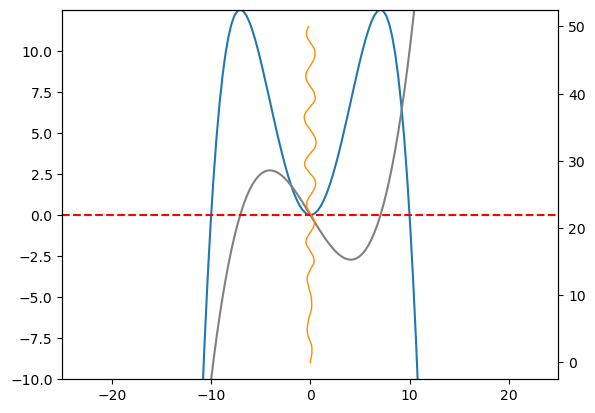

In [13]:
NOISE = 1
V0 = 0.0
DT = 0.01
MAX_TIME = 50
OMEGA = 1.0
L = 10.0

dxs, force, potential = ode_phi4_well(OMEGA, L)
stepper = create_euler_maruyama_stepper(dxs, NOISE)
xs0 = np.array([0, V0])

xs = np.linspace(-150, 150, 1000)
fs = force(xs)
vs = potential(xs)



xss, reached = iterate_until(stepper, xs0, DT, L, MAX_TIME)

fig, ax = plt.subplots()
tax = ax.twinx()
ax.plot(xs, vs)
ax.plot(xs, fs, color="gray")
ax.axhline(0, color='red', ls='--')

ts = np.arange(xss.shape[0]) * DT
tax.plot(xss[:, 0], ts, color="DarkOrange", lw=1)
ax.set_xlim(-25, 25)
ax.set_ylim(-10, vs.max())

In [29]:
def escape_time(omega, l, noise, dt, max_time):
    dxs, force, potential = ode_phi4_well(omega, l)
    xs0 = np.array([0, 0])
    create_euler_maruyama_stepper(dxs, noise)
    xss, reached = iterate_until(stepper, xs0, dt, l, max_time)
    return xss.shape[0]*dt, reached
    
def escape_stats(omega, l, noise, dt, max_time, repeats=100):
    times = []
    reaches = []
    for trial in range(repeats):
        time, reach = escape_time(omega, l, noise, dt, max_time)
        reaches.append(reach)
        if reach:
            times.append(time)
    return np.mean(reaches), np.mean(times)

In [30]:
noises = np.linspace(0, 1, 11)
reaches, times = zip(*[escape_stats(1.0, 15.0, noise, 0.01, 1000, repeats=10) for noise in tqdm.tqdm(noises)])

  0%|          | 0/11 [00:00<?, ?it/s]

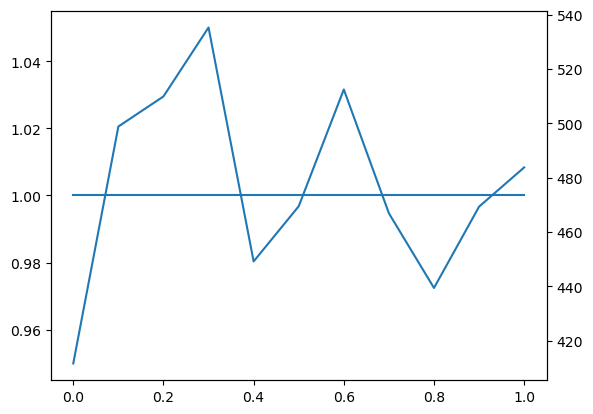

In [32]:
fig, ax = plt.subplots()
tax = ax.twinx()

ax.plot(noises, reaches)
tax.plot(noises, times)

In [ ]:
v0s = np.linspace(2, 6, 101)
ets = [probability_of_escape(1.0, 15.0, 0.0, v0, ts, repeats=1000) for v0 in tqdm.tqdm(v0s)]

In [ ]:
plt.plot(v0s, ets)
plt.xlim(0, v0s.max())